# 04 — Merchant expansion investigation queue
## Context & methods
Eligibility: latest quarter, at least 100,000 users, 1,000 merchants, one million transactions, plus observed consecutive-quarter and same-quarter-last-year transaction growth. Percentile ranks are calculated across this entire eligible universe. We then restrict the investigation pool to positive transaction QoQ/YoY and nondeclining user/merchant registrations.

Default weights: 30% YoY demand growth, 25% transactions per merchant, 25% users per merchant, 20% user scale. Equal weights and no-intensity weights (40% growth, 35% density, 25% scale) are explicit judgment scenarios. Scores are rounded to ten decimal places before ranking to preserve mathematical ties across Python and MySQL; display ties are ordered by state and district.

### Key assumptions
EXPAND means score percentile ≥75th and density-gap percentile ≥50th. DEFEND means scale percentile ≥75th and density-gap percentile <50th; remaining records at or above median score are DEVELOP, others MONITOR. These are research labels, not validated acquisition decisions. Scenario top tens use the same positive-momentum pool; global eligible ranks and investigation ranks answer different questions.

## tl;dr

- Scores **680 eligible districts** and narrows **624 positive-momentum districts** into a field-research queue.
- Explains each score factor, segment, exclusion, and ranking rule; then tests recent growth persistence and alternative weights and thresholds.
- West Godavari and Sangareddy lead; six default top-ten candidates survive removal of transaction intensity.
- Demonstrates: transparent decision scoring, deterministic ranking, sensitivity analysis, recommendation design, and limitation-aware business judgment.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from phonepe_analytics.analysis import ANALYSIS_DIR, descriptive_statistics
from phonepe_analytics.config import EDA_CHART_DIR

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})
PURPLE, TEAL, GRAY = "#5F259F", "#087F8C", "#697386"
EDA_CHART_DIR.mkdir(parents=True, exist_ok=True)


def save_chart(fig, name):
    fig.tight_layout()
    fig.savefig(EDA_CHART_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


district = pd.read_csv(ANALYSIS_DIR / "district_metrics.csv")
state = pd.read_csv(ANALYSIS_DIR / "state_metrics.csv")
national = pd.read_csv(ANALYSIS_DIR / "national_metrics.csv").sort_values("period_id")
latest_period = district.period_id.max()
latest = district.loc[district.period_id.eq(latest_period)].copy()
state_latest = state.loc[state.period_id.eq(latest_period)].copy()
eligible = pd.read_csv(ANALYSIS_DIR / "district_opportunities.csv")
period = latest.period_label.iloc[0]

## Data — exclusions, momentum and segment composition

Users below 100K             103
Merchants below 1K            71
Transactions below 1M         68
Missing comparable growth      0
Name: Districts (reasons can overlap), dtype: int64

**Insight:** 680 of 783 districts meet scale/history rules; 624 also meet the positive-momentum conditions. Exclusions narrow comparability, not business viability: smaller markets can still merit local research. The threshold scenario below checks that this choice does not go unexamined.

,districts,median_score,median_growth,median_users,median_users_per_merchant
business_segment,,,,,
EXPAND,132,68.678,0.280,850884.5,18.910
DEFEND,121,46.495,0.245,1843408.0,12.588
DEVELOP,154,54.750,0.258,570962.5,16.948
MONITOR,273,39.411,0.226,528271.0,14.479


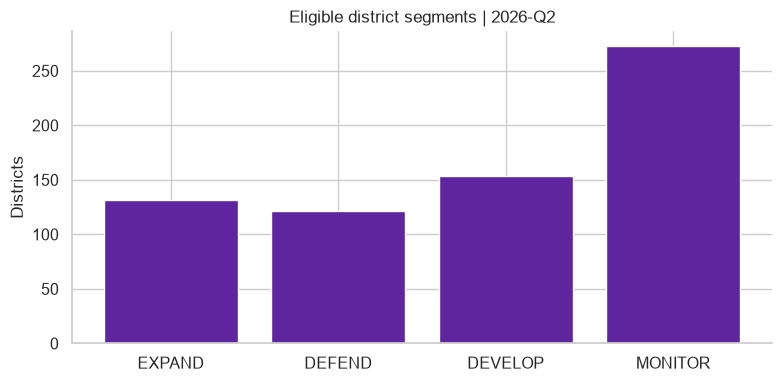

**Insight:** segment medians describe the practical meaning of the deterministic rules. EXPAND combines relative demand/scale with a registration-gap signal, while DEFEND identifies large user bases with denser registrations. These labels cannot establish saturation or justify a budget without active-merchant evidence.

In [2]:
from phonepe_analytics.analysis import shortlist_sensitivity
from phonepe_analytics.metrics import score_opportunities

pool = pd.read_csv(ANALYSIS_DIR / "investigation_shortlist.csv")
sensitivity, top = shortlist_sensitivity(pool)
exclusions = pd.Series(
    {
        "Users below 100K": latest.registered_users.lt(100000).sum(),
        "Merchants below 1K": latest.registered_merchants.lt(1000).sum(),
        "Transactions below 1M": latest.transaction_count.lt(1000000).sum(),
        "Missing comparable growth": latest[["transaction_qoq", "transaction_yoy"]]
        .isna()
        .any(axis=1)
        .sum(),
    },
    name="Districts (reasons can overlap)",
)
display(exclusions)
display(
    Markdown(
        f"**Insight:** {len(eligible)} of {len(latest)} districts meet scale/history rules; "
        f"{len(pool)} also meet the positive-momentum conditions. Exclusions narrow "
        "comparability, not business viability: smaller markets can still merit local "
        "research. The threshold scenario below checks that this choice does not go unexamined."
    )
)
segment_order = ["EXPAND", "DEFEND", "DEVELOP", "MONITOR"]
segment = (
    eligible.groupby("business_segment")
    .agg(
        districts=("district", "size"),
        median_score=("opportunity_score", "median"),
        median_growth=("transaction_yoy", "median"),
        median_users=("registered_users", "median"),
        median_users_per_merchant=("users_per_merchant", "median"),
    )
    .reindex(segment_order)
)
display(segment.round(3))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(segment.index, segment.districts, color=PURPLE)
ax.set(title=f"Eligible district segments | {period}", ylabel="Districts")
save_chart(fig, "04_segment_composition")
display(
    Markdown(
        "**Insight:** segment medians describe the practical meaning of the deterministic "
        "rules. EXPAND combines relative demand/scale with a registration-gap signal, "
        "while DEFEND identifies large user bases with denser registrations. These "
        "labels cannot establish saturation or justify a budget without active-merchant evidence."
    )
)

## Results — score distributions and the investigation shortlist

,count,mean,std,min,10%,25%,50%,75%,90%,95%,max,missing,skewness,iqr,iqr_outliers
metric,,,,,,,,,,,,,,,
opportunity_score,680.0,50.0,14.31,11.66,32.05,39.72,49.42,60.19,69.77,74.77,86.68,0,0.13,20.47,0
equal_weight_score,680.0,50.0,14.09,11.45,32.01,40.60,48.49,59.72,69.29,74.30,86.38,0,0.12,19.12,1
no_intensity_score,680.0,50.0,13.64,9.28,32.02,40.68,49.97,59.50,67.72,71.83,82.71,0,-0.05,18.83,1


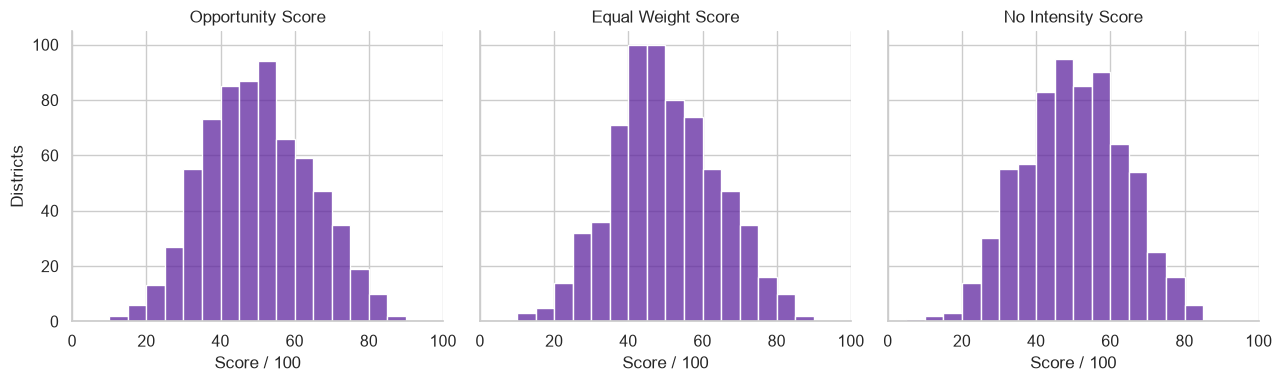

**Insight:** alternative weightings change score spread even within the same eligible population. A score of 80 is a weighted relative position, not an 80% chance of success. Individual factor percentiles are rank transformations and have near-uniform marginal distributions by construction; their joint pattern and shortlist sensitivity are the informative checks.

,investigation_rank,state,district,opportunity_score,transaction_yoy,users_per_merchant,registered_merchants,positive_yoy_quarters_last4,equal_weight_shortlist_rank,no_intensity_shortlist_rank,recommendation
24,1,andhra pradesh,west godavari,86.679,0.305,24.617,48583,4.0,1,2,Priority field validation
511,2,telangana,sangareddy,86.274,0.323,18.019,102640,4.0,2,4,Priority field validation
6,3,andhra pradesh,dr br ambedkar konaseema,84.993,0.330,20.384,45653,4.0,5,6,Priority field validation
7,4,andhra pradesh,east godavari,84.492,0.322,18.276,74989,4.0,4,7,Priority field validation
18,5,andhra pradesh,sri potti sriramulu nellore,84.116,0.305,18.486,93583,4.0,3,9,Priority field validation
0,6,andhra pradesh,alluri sitharama raju,83.645,0.379,36.604,11247,4.0,12,8,Priority field validation
21,7,andhra pradesh,tirupati,82.305,0.282,18.664,118910,4.0,6,15,Investigate; sensitive to intensity weighting
8,8,andhra pradesh,eluru,81.355,0.292,18.912,67639,4.0,7,20,Investigate; sensitive to intensity weighting
254,9,karnataka,mandya,81.082,0.282,23.764,41069,4.0,10,19,Investigate; sensitive to intensity weighting
248,10,karnataka,hassan,80.265,0.264,26.220,42357,4.0,9,22,Investigate; sensitive to intensity weighting


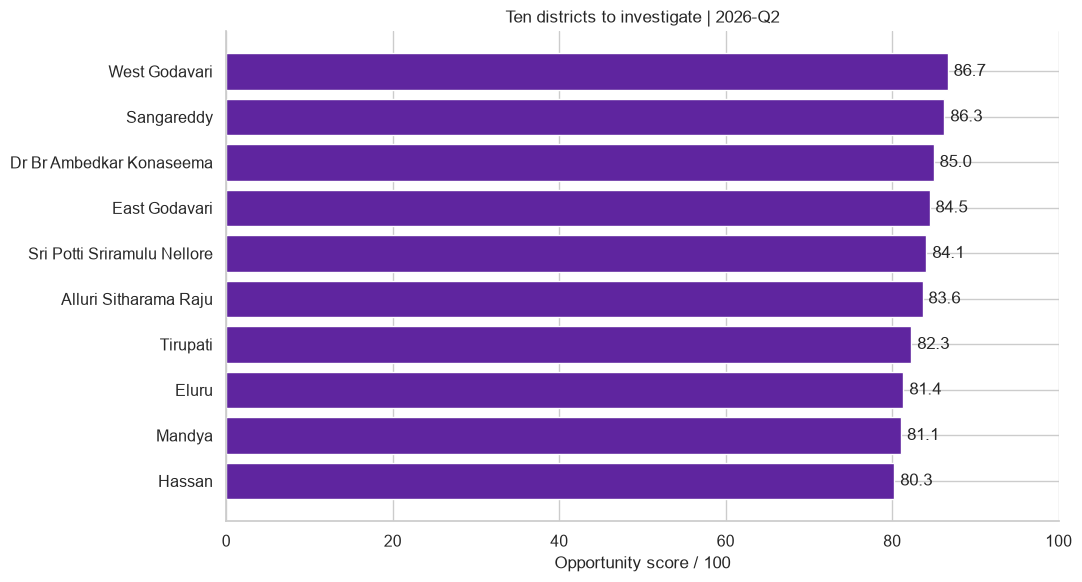

**Insight:** West Godavari (86.7) and Sangareddy (86.3) lead the queue. 7 of ten are in Andhra Pradesh. This is a strong concentration of research signals, but also a reason to validate local geography and category mix before concentrating acquisition spend.

In [3]:
scores = ["opportunity_score", "equal_weight_score", "no_intensity_score"]
display(descriptive_statistics(eligible, scores).round(2))
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for ax, score in zip(axes, scores, strict=True):
    sns.histplot(eligible[score], bins=np.linspace(0, 100, 21), color=PURPLE, ax=ax)
    ax.set(
        title=score.replace("_", " ").title(),
        xlabel="Score / 100",
        ylabel="Districts",
        xlim=(0, 100),
    )
save_chart(fig, "04_score_distributions")
display(
    Markdown(
        "**Insight:** alternative weightings change score spread even within the same "
        "eligible population. A score of 80 is a weighted relative position, not an "
        "80% chance of success. Individual factor percentiles are rank transformations "
        "and have near-uniform marginal distributions by construction; their joint "
        "pattern and shortlist sensitivity are the informative checks."
    )
)
display(
    top[
        [
            "investigation_rank",
            "state",
            "district",
            "opportunity_score",
            "transaction_yoy",
            "users_per_merchant",
            "registered_merchants",
            "positive_yoy_quarters_last4",
            "equal_weight_shortlist_rank",
            "no_intensity_shortlist_rank",
            "recommendation",
        ]
    ].round(3)
)
fig, ax = plt.subplots(figsize=(11, 6))
ranked = top.iloc[::-1]
ax.barh(ranked.district.str.title(), ranked.opportunity_score, color=PURPLE)
for i, score in enumerate(ranked.opportunity_score):
    ax.text(score + 0.7, i, f"{score:.1f}", va="center")
ax.set(
    xlim=(0, 100),
    title=f"Ten districts to investigate | {period}",
    xlabel="Opportunity score / 100",
)
save_chart(fig, "04_district_shortlist")
display(
    Markdown(
        f"**Insight:** {top.iloc[0].district.title()} ({top.iloc[0].opportunity_score:.1f}) and "
        f"{top.iloc[1].district.title()} ({top.iloc[1].opportunity_score:.1f}) lead the queue. "
        f"{top.state.value_counts().iloc[0]} of ten are in "
        f"{top.state.value_counts().index[0].title()}. "
        "This is a strong concentration of research signals, but also a reason to validate local "
        "geography and category mix before concentrating acquisition spend."
    )
)

### Multivariate score anatomy and recent persistence

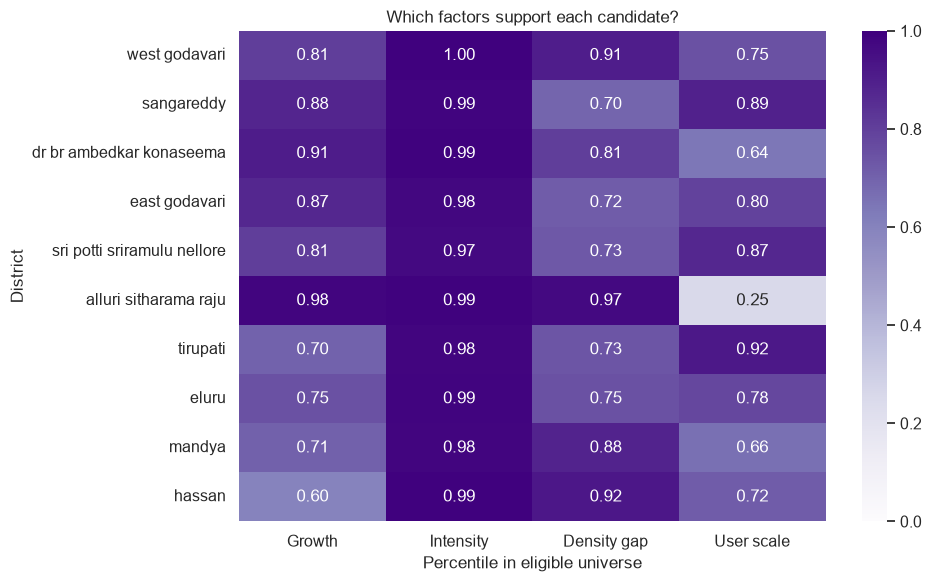

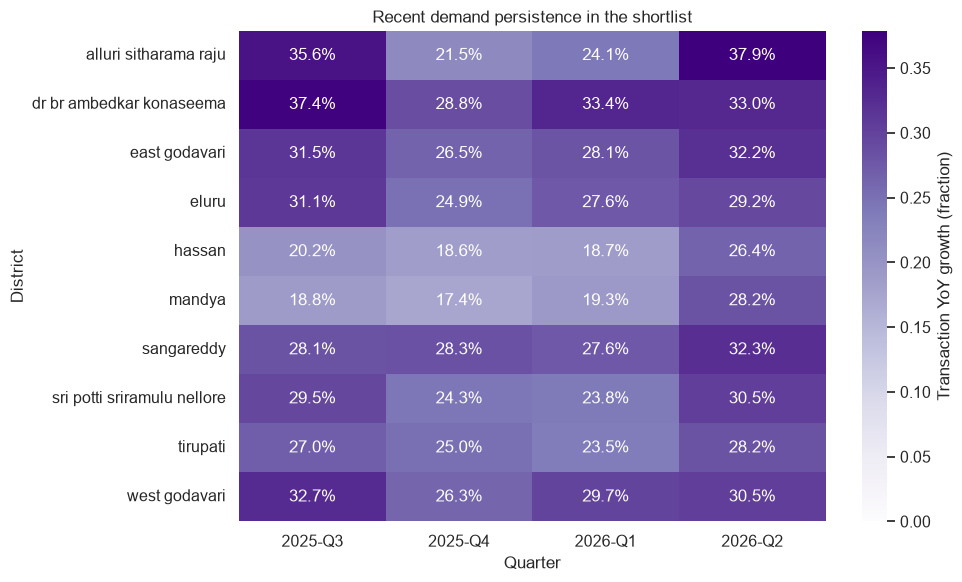

**Insight:** 10 of ten shortlisted districts have positive YoY demand growth in all four latest calendar quarters. The factor heatmap shows that candidates do not all rely on the same mix of size, density and intensity. Persistence strengthens the research case over a single-quarter spike, but overlapping YoY windows are not four independent replications and do not guarantee future growth.

In [4]:
factors = [
    "growth_percentile",
    "intensity_percentile",
    "low_penetration_percentile",
    "scale_percentile",
]
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    top.set_index("district")[factors],
    cmap="Purples",
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,
    ax=ax,
    xticklabels=["Growth", "Intensity", "Density gap", "User scale"],
)
ax.set(
    title="Which factors support each candidate?",
    xlabel="Percentile in eligible universe",
    ylabel="District",
)
save_chart(fig, "04_score_factor_profiles")
history = district.loc[
    district.district_key.isin(top.district_key)
    & district.period_id.between(latest_period - 3, latest_period)
]
persistence = history.pivot(index="district", columns="period_label", values="transaction_yoy")
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    persistence,
    annot=True,
    fmt=".1%",
    cmap="Purples",
    vmin=0,
    ax=ax,
    cbar_kws={"label": "Transaction YoY growth (fraction)"},
)
ax.set(title="Recent demand persistence in the shortlist", xlabel="Quarter", ylabel="District")
save_chart(fig, "04_shortlist_growth_persistence")
display(
    Markdown(
        f"**Insight:** {(persistence.gt(0).sum(axis=1).eq(4)).sum()} of ten shortlisted districts "
        "have positive YoY demand growth in all four latest calendar quarters. The factor heatmap "
        "shows that candidates do not all rely on the same mix of size, density and intensity. "
        "Persistence strengthens the research case over a single-quarter spike, but overlapping "
        "YoY windows are not four independent replications and do not guarantee future growth."
    )
)

### Weight and eligibility sensitivity

,scenario,top10_overlap
0,opportunity,10
1,equal_weight,9
2,no_intensity,6


,state,district,opportunity_score,registered_users,registered_merchants
951,andhra pradesh,west godavari,83.18,1195968,48583.0
22371,telangana,sangareddy,82.51,1849509,102640.0
339,andhra pradesh,dr br ambedkar konaseema,81.54,930577,45653.0
135,andhra pradesh,alluri sitharama raju,81.52,411684,11247.0
373,andhra pradesh,east godavari,80.74,1370485,74989.0
747,andhra pradesh,sri potti sriramulu nellore,80.19,1729942,93583.0
1699,arunachal pradesh,shi yomi,79.97,6109,15.0
16319,nagaland,mon,79.96,44304,299.0
20059,sikkim,mangan,79.55,32027,333.0
15095,manipur,pherzawl,79.39,1928,3.0


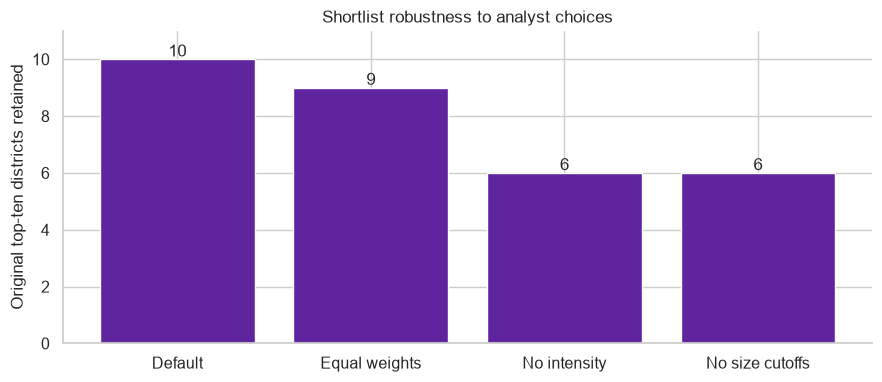

**Insight:** equal weights retain 9/10; removing intensity retains 6/10; removing size cutoffs retains 6/10. Exact rank is sensitive to the analyst's objective and eligibility rules. The no-intensity survivors deserve stronger research priority because they depend less on a shared-denominator demand proxy. The broader scenario reranks its own universe, so its scores are not directly comparable with baseline scores; overlap is the appropriate comparison.

In [5]:
broad = score_opportunities(latest, minimum_users=0, minimum_merchants=1, minimum_transactions=0)
broad_pool = broad.loc[
    broad.transaction_qoq.gt(0)
    & broad.transaction_yoy.gt(0)
    & broad.user_qoq.ge(0)
    & broad.merchant_qoq.ge(0)
]
broad_top = broad_pool.head(10)
broad_keys = set(broad_top.state + "|" + broad_top.district)
threshold_overlap = len(set(top.district_key) & broad_keys)
display(sensitivity)
display(
    broad_top[
        ["state", "district", "opportunity_score", "registered_users", "registered_merchants"]
    ].round(2)
)
fig, ax = plt.subplots(figsize=(9, 4))
names = ["Default", "Equal weights", "No intensity", "No size cutoffs"]
values = [*sensitivity.top10_overlap, threshold_overlap]
ax.bar(names, values, color=PURPLE)
for i, value in enumerate(values):
    ax.text(i, value + 0.1, str(value), ha="center")
ax.set(
    ylim=(0, 11),
    ylabel="Original top-ten districts retained",
    title="Shortlist robustness to analyst choices",
)
save_chart(fig, "04_score_sensitivity")
display(
    Markdown(
        f"**Insight:** equal weights retain {values[1]}/10; removing intensity retains "
        f"{values[2]}/10; "
        f"removing size cutoffs retains {threshold_overlap}/10. Exact rank is sensitive to the "
        "analyst's objective and eligibility rules. The no-intensity survivors deserve stronger "
        "research priority because they depend less on a shared-denominator demand proxy. "
        "The broader scenario reranks its own universe, so its scores are not directly comparable "
        "with baseline scores; overlap is the appropriate comparison."
    )
)

## Takeaways — field research before acquisition spend

In [6]:
stronger = top.loc[top.no_intensity_shortlist_rank.le(10)]
display(
    Markdown(
        "**Priority field validation:** " + ", ".join(stronger.district.str.title()) + ". "
        "Check active acceptance, competing payment options, merchant categories, "
        "eligible local shop counts, sales travel effort and acquisition cost. "
        "Use activation and 30-day merchant activity when assessing any later rollout; "
        "Pulse alone cannot establish conversion, profit, ROI or realized impact."
    )
)
assert top.opportunity_score.between(0, 100).all()
assert top.district_key.is_unique

**Priority field validation:** West Godavari, Sangareddy, Dr Br Ambedkar Konaseema, East Godavari, Sri Potti Sriramulu Nellore, Alluri Sitharama Raju. Check active acceptance, competing payment options, merchant categories, eligible local shop counts, sales travel effort and acquisition cost. Use activation and 30-day merchant activity when assessing any later rollout; Pulse alone cannot establish conversion, profit, ROI or realized impact.